In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from src.data_air import fetch_all_cities

# Настройка отображения
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 5)

print("Импорты загружены ")

Импорты загружены 


In [2]:
df = fetch_all_cities(past_days=7, forecast_days=0)

print(f"Размер таблицы: {df.shape}")
print(f"Колонки: {list(df.columns)}")
df.head()

Загрузка: Москва...
Загрузка: Санкт-Петербург...
Загрузка: Новосибирск...
Загрузка: Екатеринбург...
Загрузка: Казань...
Загрузка: Краснодар...
Загрузка: Владивосток...
Загрузка: Мурманск...
Загрузка: Сочи...
Загрузка: Иркутск...

Всего записей: 1680
Размер таблицы: (1680, 10)
Колонки: ['time', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'city', 'latitude', 'longitude']


,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,city,latitude,longitude
0,2026-09-12 00:00:00,26.2,19.2,248.0,43.7,25.4,14.0,Москва,55.7558,37.6173
1,2026-09-12 01:00:00,20.5,16.3,219.0,37.3,20.6,19.0,Москва,55.7558,37.6173
2,2026-09-12 02:00:00,17.9,14.1,197.0,29.3,19.7,23.0,Москва,55.7558,37.6173
3,2026-09-12 03:00:00,16.4,13.5,204.0,25.7,17.8,27.0,Москва,55.7558,37.6173
4,2026-09-12 04:00:00,19.8,15.5,199.0,24.6,21.3,24.0,Москва,55.7558,37.6173


In [3]:
df.describe()

,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,latitude,longitude
count,1680,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000
mean,2026-09-15 18:42:00,12.682857,9.924286,214.140476,15.676131,8.459702,52.699405,53.634980,60.853150
min,2026-09-12 00:00:00,0.100000,0.100000,105.000000,0.100000,0.400000,0.000000,43.115500,30.335100
25%,2026-09-14 01:00:00,5.800000,4.400000,138.000000,2.900000,1.700000,39.000000,45.035500,37.617300
50%,2026-09-15 19:00:00,9.000000,6.700000,162.000000,6.500000,2.900000,52.000000,55.382100,44.394600
75%,2026-09-17 13:00:00,13.400000,10.300000,217.000000,18.050000,5.800000,69.000000,56.838900,82.935700
max,2026-09-19 23:00:00,191.000000,152.600000,1833.000000,164.400000,208.900000,118.000000,68.958500,131.885500
std,NaN,15.305232,12.435170,160.407608,21.425565,17.193830,25.009768,7.640209,32.763174


In [4]:
print("Пропуски по колонкам:")
print(df.isnull().sum())

print("\nДоля пропусков, %:")
print((df.isnull().sum() / len(df) * 100).round(2))

Пропуски по колонкам:
time                0
pm10                0
pm2_5               0
carbon_monoxide     0
nitrogen_dioxide    0
sulphur_dioxide     0
ozone               0
city                0
latitude            0
longitude           0
dtype: int64

Доля пропусков, %:
time                0.0
pm10                0.0
pm2_5               0.0
carbon_monoxide     0.0
nitrogen_dioxide    0.0
sulphur_dioxide     0.0
ozone               0.0
city                0.0
latitude            0.0
longitude           0.0
dtype: float64


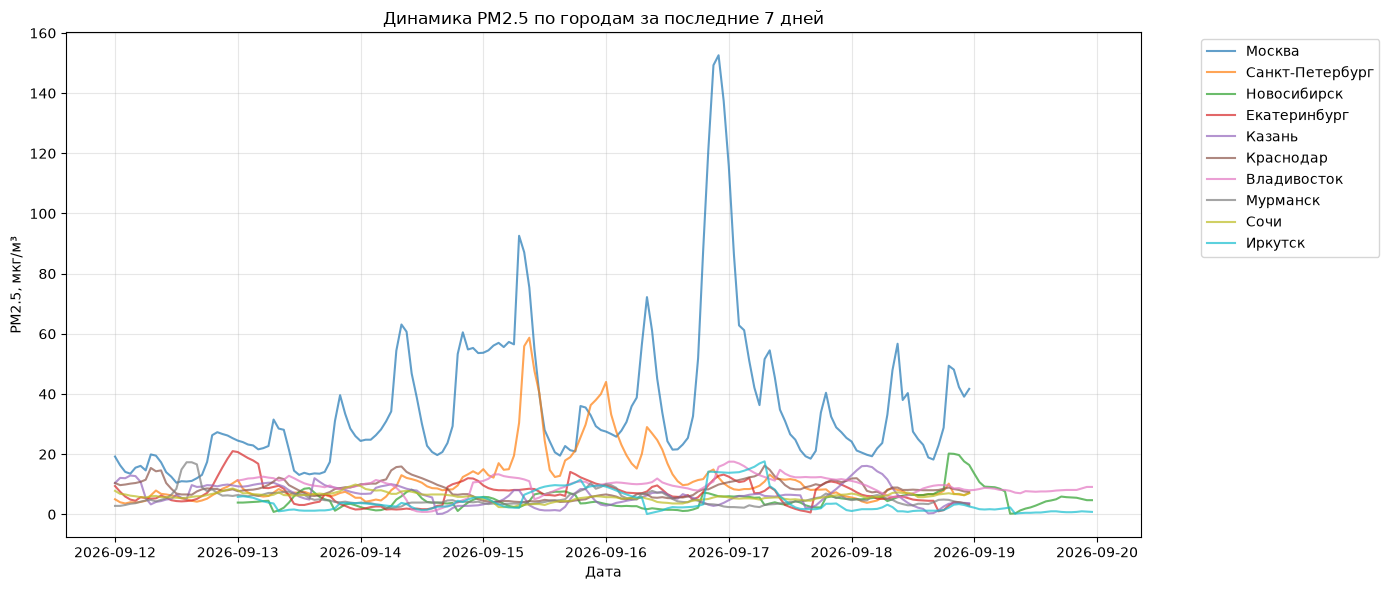

In [5]:
plt.figure(figsize=(14, 6))

for city in df['city'].unique():
    city_data = df[df['city'] == city]
    plt.plot(city_data['time'], city_data['pm2_5'], label=city, alpha=0.7)

plt.xlabel('Дата')
plt.ylabel('PM2.5, мкг/м³')
plt.title('Динамика PM2.5 по городам за последние 7 дней')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Проверка модулей filters и plots
from src.filters import get_city_current, get_city_stats
from src.plots import create_map, plot_timeseries, plot_bar_avg

# Текущие значения по городам
current = get_city_current(df)
print("Текущие значения PM2.5:")
print(current[["city", "pm2_5"]].sort_values("pm2_5", ascending=False))

# Карта
m = create_map(current, pollutant="pm2_5")
m  

Текущие значения PM2.5:
              city  pm2_5
4           Москва   41.7
8      Владивосток    9.1
6        Краснодар    7.4
3  Санкт-Петербург    7.1
2             Сочи    7.0
7      Новосибирск    4.7
0           Казань    3.7
5     Екатеринбург    3.4
1         Мурманск    2.9
9          Иркутск    0.8


In [8]:
from src.plots import create_map

current = get_city_current(df)
m = create_map(current, pollutant="pm2_5")

# Сохраняем в HTML-файл
m.save("../reports/air_quality_map.html")
print("Карта сохранена в reports/air_quality_map.html")

Карта сохранена в reports/air_quality_map.html
